# PETH tutorial

Load synchronized spikes and stimulus events from the database, then plot one unit's raster and peri-event time histogram (PETH).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem
from spks.event_aligned import population_peth
from spks.viz import plot_event_aligned_raster

from thesis.ephys.trials import build_trial_table
from thesis.ephys.units import fetch_unit_table

warnings.filterwarnings("ignore", category=UserWarning, module="datajoint.plugin")

plt.rcParams["text.usetex"] = False
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = 'svg'
%matplotlib widget
%load_ext autoreload
%autoreload 2

## Load one session from the database

In [2]:
subject = "GRB006"
session = "20240821_121447"
unit_criteria_id = 1
stability_param_id = 0
unit_id = 20

unit_table = fetch_unit_table(subject, session, unit_criteria_id, stability_param_id)
trial_table = build_trial_table(subject, session)

spike_times_s = np.asarray(
    unit_table.set_index("unit_id").loc[unit_id, "spike_times_s"], dtype=float
)
first_stim_times_s = np.asarray(
    [times[0] for times in trial_table["stim_pulse_times_s"] if times],
    dtype=float,
)
print(f"Loaded unit {unit_id} and {len(first_stim_times_s)} stimulus trials.")

[2026-08-24 19:08:27,703][INFO]: DataJoint 0.14.8 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


Loaded unit 20 and 295 stimulus trials.


## Choose the alignment window

In [3]:
binwidth_ms = 10
pre_seconds = 0.1
post_seconds = 0.15

## Plot the event-aligned raster

Text(0, 0.5, 'Trial')

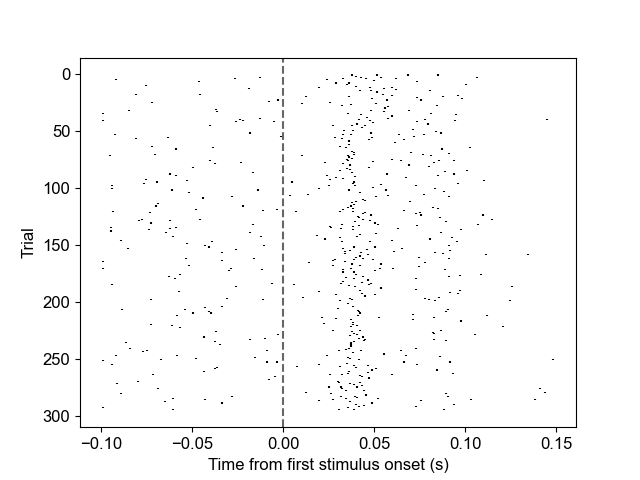

In [4]:
fig, ax = plt.subplots(1)
plot_event_aligned_raster(
    event_times=first_stim_times_s,
    spike_times=spike_times_s,
    pre_seconds=pre_seconds,
    post_seconds=post_seconds,
    ax=ax,
)

ax.axvline(0, color="0.4", linestyle="--")
ax.set_xlabel("Time from first stimulus onset (s)")
ax.set_ylabel("Trial")

## Compute and plot the PETH

Text(0, 0.5, 'Spikes s$^{-1}$')

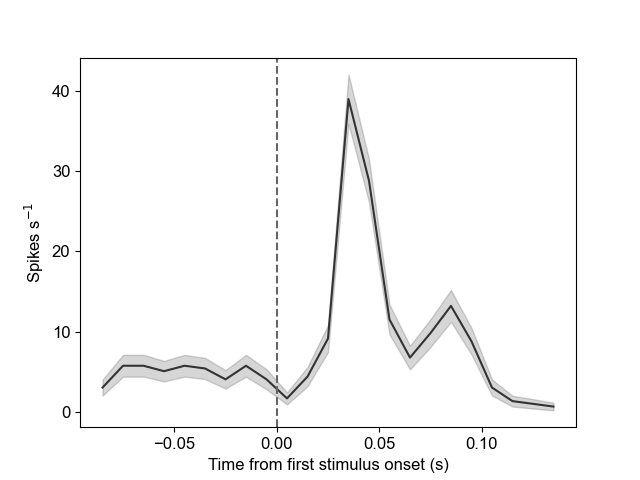

In [5]:
peth_counts, bin_edges, _ = population_peth(
    all_spike_times=[spike_times_s],
    alignment_times=first_stim_times_s,
    pre_seconds=pre_seconds,
    post_seconds=post_seconds,
    binwidth_ms=binwidth_ms,
)
peth_spikes_per_second = peth_counts / (binwidth_ms / 1000)

trial_peth = peth_spikes_per_second[0]
mean_peth = trial_peth.mean(axis=0)
sem_peth = sem(trial_peth, axis=0)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, ax = plt.subplots(1)
ax.plot(bin_centers, mean_peth, color="0.2")
ax.fill_between(
    bin_centers, mean_peth - sem_peth, mean_peth + sem_peth, color="0.2", alpha=0.2
)
ax.axvline(0, color="0.4", linestyle="--")
ax.set_xlabel("Time from first stimulus onset (s)")
ax.set_ylabel("Spikes s$^{-1}$")